In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from voice_access_pipeline import (
    DataPrepConfig,
    ModelConfig,
    TrainConfig,
    ExperimentConfig,
    clone_experiment,
    prepare_data_artifacts,
    train_experiment,
    evaluate_saved_experiment,
    compare_experiments,
)

C:\Users\idani\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Settings

In [2]:
DATA_CONFIG = DataPrepConfig(
    source_dir=Path(r"VOiCES_devkit/source-16k"),
    work_dir=Path(r"voice_access_files"),
    allow_speakers=None,
    seed=123,
    train_ratio=0.7,
    valid_ratio=0.1,
    target_allow_speakers_in_valid=2,
    segment_seconds=3.0,
    keep_remainder=False,
    trim_silence=True,
    trim_top_db=25,
    image_size=128,
    n_mels=128,
)

MODEL_CONFIG = ModelConfig(
    dropout=0.35,
    use_batchnorm=True,
)

TRAIN_CONFIG = TrainConfig(
    batch_size=32,
    epochs=15,
    lr=3e-4,
    weight_decay=1e-4,
    early_stopping_patience=6,
    lr_scheduler_patience=2,
    lr_scheduler_factor=0.5,
    max_grad_norm=5.0,
    aggregation_method="top3mean",
    augment=True,
)

BASE_EXPERIMENT = ExperimentConfig(
    experiment_name="rescnn_adamw_speaker_metrics",
    data=DATA_CONFIG,
    model=MODEL_CONFIG,
    train=TRAIN_CONFIG,
)

BASE_EXPERIMENT

ExperimentConfig(experiment_name='rescnn_adamw_speaker_metrics', data=DataPrepConfig(source_dir=WindowsPath('VOiCES_devkit/source-16k'), work_dir=WindowsPath('voice_access_files'), allow_speakers=None, seed=123, train_ratio=0.7, valid_ratio=0.1, target_allow_speakers_in_valid=2, segment_seconds=3.0, keep_remainder=False, trim_silence=True, trim_top_db=25, image_size=128, n_mels=128), model=ModelConfig(dropout=0.35, use_batchnorm=True), train=TrainConfig(batch_size=32, epochs=15, lr=0.0003, weight_decay=0.0001, early_stopping_patience=6, lr_scheduler_patience=2, lr_scheduler_factor=0.5, max_grad_norm=5.0, aggregation_method='top3mean', augment=True, device='cpu', num_workers=None))

## 2. Data preparing



In [5]:
artifacts = prepare_data_artifacts(
    config=DATA_CONFIG,
    clean_intermediate=False,
    rebuild_recording_meta=True,
    rebuild_segments=True,
    rebuild_spectrograms=True,
)

print(artifacts['recording_meta'].shape)
print(artifacts['segment_meta'].shape)
print(artifacts['spectrogram_meta'].shape)

display(artifacts['recording_meta'].head())

Building spectrograms: 100%|██████████| 2826/2826 [00:40<00:00, 70.35it/s]

(600, 6)
(2826, 12)
(2826, 9)


,recording_id,speaker,label,class_name,split,audio_path
0,sp0118__Lab41-SRI-VOiCES-src-sp0118-ch121721-s...,sp0118,0,not_allow,test,VOiCES_devkit\source-16k\sp0118\Lab41-SRI-VOiC...
1,sp0118__Lab41-SRI-VOiCES-src-sp0118-ch124588-s...,sp0118,0,not_allow,test,VOiCES_devkit\source-16k\sp0118\Lab41-SRI-VOiC...
2,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...
3,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch124002-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...
4,sp0174__Lab41-SRI-VOiCES-src-sp0174-ch050561-s...,sp0174,0,not_allow,test,VOiCES_devkit\source-16k\sp0174\Lab41-SRI-VOiC...


(128, 128)


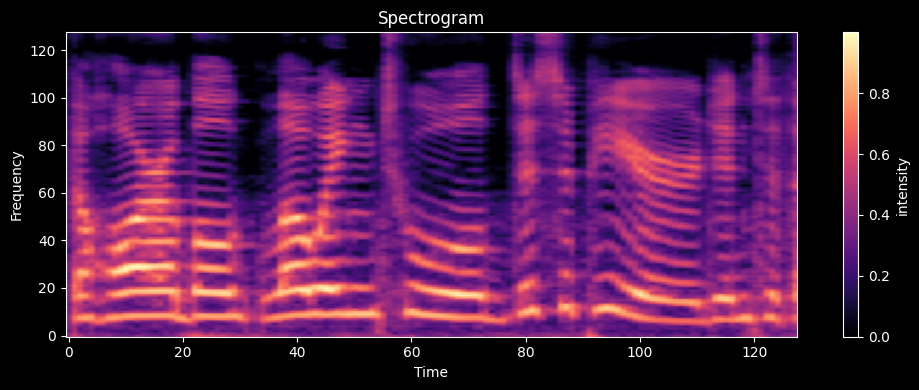

In [3]:
spec = np.load("voice_access_files\\spectrograms_npy\\test\\allow\\sp0083\\sp0083__Lab41-SRI-VOiCES-src-sp0083-ch009960-sg0042__seg0000.npy")

print(spec.shape)

plt.figure(figsize=(10, 4))
plt.imshow(spec, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="intensity")
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 3. Training



In [6]:
history_df = train_experiment(
    config=BASE_EXPERIMENT,
    rebuild_data=False,
    clean_intermediate=False,
)

display(history_df.tail())

Training epochs:  60%|██████    | 9/15 [21:19<14:12, 142.14s/it, best=4.1235, train_loss=1.5502, valid_loss=9.2232]


Early stopping at epoch 10. Best epoch: 4


,epoch,train_loss,valid_loss,pos_weight,lr,best_threshold,best_valid_balanced_accuracy
5,6,1.696202,4.888194,80.458333,0.000300,0.33,0.741667
6,7,1.660243,4.356586,80.458333,0.000150,0.33,0.741667
7,8,2.050036,5.502335,80.458333,0.000150,0.33,0.741667
8,9,1.458792,8.435684,80.458333,0.000150,0.33,0.741667
9,10,1.550194,9.223168,80.458333,0.000075,0.33,0.741667


## 4. Model evaluating


In [7]:
results_df = evaluate_saved_experiment(BASE_EXPERIMENT)

print(results_df)

                experiment_name  threshold aggregation_method  split  \
0  rescnn_adamw_speaker_metrics       0.33           top3mean  train   
1  rescnn_adamw_speaker_metrics       0.33           top3mean  valid   
2  rescnn_adamw_speaker_metrics       0.33           top3mean   test   

   segment_n_total  segment_n_allow  segment_n_not_allow  \
0             1955               24                 1931   
1              291               10                  281   
2              580               15                  565   

   segment_false_accept  segment_false_reject  segment_far  ...  \
0                   697                     2     0.360953  ...   
1                   122                     5     0.434164  ...   
2                   234                     5     0.414159  ...   

   speaker_macro_far_recording  speaker_macro_frr_recording  \
0                     0.478155                     0.000000   
1                     0.516667                     0.000000   
2           

## 5. Some experiments



In [ ]:
EXPERIMENTS = [
    clone_experiment(
        BASE_EXPERIMENT,
        experiment_name='exp_rescnn_top3mean',
    ),
    clone_experiment(
        BASE_EXPERIMENT,
        experiment_name='exp_rescnn_mean',
        train_updates={'aggregation_method': 'mean'},
    ),
    clone_experiment(
        BASE_EXPERIMENT,
        experiment_name='exp_no_augment',
        train_updates={'augment': False},
    ),
    clone_experiment(
        BASE_EXPERIMENT,
        experiment_name='exp_more_dropout',
        model_updates={'dropout': 0.50},
    ),
    clone_experiment(
        BASE_EXPERIMENT,
        experiment_name='exp_no_batchnorm',
        model_updates={'use_batchnorm': False},
    ),
]

comparison_df = compare_experiments(
    EXPERIMENTS,
    rebuild_data_for_first=False,
    clean_intermediate_for_first=False,
)

display(comparison_df[[
    'experiment_name',
    'threshold',
    'aggregation_method',
    'test_far', 'test_frr', 'test_balanced_error',
    'test_gap_far_frr',
    'test_macro_far_speaker', 'test_macro_frr_speaker',
    'test_far_speaker_hard', 'test_frr_speaker_hard',
    'test_balanced_error_speaker_hard',
]])

## 6. Add new person


In [ ]:
# from voice_access_pipeline import add_new_allowed_speaker_recordings, extend_allow_speakers

# add_new_allowed_speaker_recordings(
#     new_speaker_dir=Path(r"new_person_recordings"),
#     source_dir=DATA_CONFIG.source_dir,
#     speaker_name="new_person",
# )

# DATA_CONFIG_EXTENDED = extend_allow_speakers(DATA_CONFIG, new_speaker_name="new_person")
# EXPERIMENT_EXTENDED = clone_experiment(
#     BASE_EXPERIMENT,
#     experiment_name="exp_after_adding_new_person",
#     data_updates={'allow_speakers': DATA_CONFIG_EXTENDED.allow_speakers},
# )